In [2]:
import csv
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as AF
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm



In [3]:
# Data + target pipeline

def split_number(n: int) -> Tuple[List[int], List[int]]:
    s = str(n).zfill(6)
    digits = [int(c) for c in s]
    thousands = digits[:3]
    rest = digits[3:]
    return thousands, rest


def thousand_form_class(thousands_digits: List[int]) -> int:
    t = int("".join(map(str, thousands_digits)))
    if t % 10 == 1 and t % 100 != 11:
        return 0  # тысяча
    if 2 <= t % 10 <= 4 and not (12 <= t % 100 <= 14):
        return 1  # тысячи
    return 2  # тысяч


def number_to_target(number_text: str) -> Tuple[List[int], int]:
    n = int(number_text)
    thousands, rest = split_number(n)
    digits6 = thousands + rest
    form = thousand_form_class(thousands)
    return digits6, form


def digits_to_number(digits6: List[int]) -> int:
    return int("".join(map(str, digits6)))


def levenshtein(a: str, b: str) -> int:
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i]
        for j, cb in enumerate(b, start=1):
            ins = curr[j - 1] + 1
            dele = prev[j] + 1
            sub = prev[j - 1] + (ca != cb)
            curr.append(min(ins, dele, sub))
        prev = curr
    return prev[-1]


def cer_numbers(ref_number: int, hyp_number: int) -> float:
    ref = str(ref_number)
    hyp = str(hyp_number)
    if len(ref) == 0:
        return 0.0 if len(hyp) == 0 else 1.0
    return levenshtein(ref, hyp) / len(ref)


class SpokenNumbersDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        dataset_root: str | Path,
        target_sample_rate: int = 16_000,
        is_train: bool = False,
        speed_perturb_probs: Tuple[float, float, float] = (0.25, 0.5, 0.25),
    ) -> None:
        self.csv_path = Path(csv_path)
        self.dataset_root = Path(dataset_root)
        self.target_sample_rate = target_sample_rate
        self.is_train = is_train
        self.speed_choices = (0.9, 1.0, 1.1)
        self.speed_probs = speed_perturb_probs

        with self.csv_path.open("r", encoding="utf-8", newline="") as f:
            self.rows = list(csv.DictReader(f))

        self._resamplers: Dict[int, torchaudio.transforms.Resample] = {}

    def __len__(self) -> int:
        return len(self.rows)

    def _get_resampler(self, orig_sr: int) -> torchaudio.transforms.Resample:
        if orig_sr not in self._resamplers:
            self._resamplers[orig_sr] = torchaudio.transforms.Resample(orig_sr, self.target_sample_rate)
        return self._resamplers[orig_sr]

    def _augment_waveform(self, waveform: torch.Tensor, sample_rate: int) -> Tuple[torch.Tensor, int]:
        # Speed perturbation 0.9 / 1.0 / 1.1
        factor = random.choices(self.speed_choices, weights=self.speed_probs, k=1)[0]
        if factor != 1.0:
            new_sr = max(1, int(sample_rate * factor))
            waveform = AF.resample(waveform, sample_rate, new_sr)
            sample_rate = new_sr

        # Additive noise with random SNR in [10, 30] dB.
        snr_db = random.uniform(10.0, 30.0)
        noise = torch.randn_like(waveform)
        sig_pow = waveform.pow(2).mean().clamp_min(1e-8)
        noise_pow = noise.pow(2).mean().clamp_min(1e-8)
        noise_scale = torch.sqrt(sig_pow / (noise_pow * (10 ** (snr_db / 10.0))))
        waveform = waveform + noise_scale * noise

        # Random gain in +/- 6 dB.
        gain_db = random.uniform(-6.0, 6.0)
        waveform = waveform * (10 ** (gain_db / 20.0))
        waveform = waveform.clamp(-1.0, 1.0)
        return waveform, sample_rate

    def __getitem__(self, index: int) -> Dict[str, Any]:
        row = self.rows[index]
        audio_path = self.dataset_root / row["filename"]

        waveform, sample_rate = torchaudio.load(str(audio_path))
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if self.is_train:
            waveform, sample_rate = self._augment_waveform(waveform, sample_rate)

        if sample_rate != self.target_sample_rate:
            waveform = self._get_resampler(sample_rate)(waveform)
            sample_rate = self.target_sample_rate

        waveform = waveform.squeeze(0)

        label_text: Optional[str] = None
        if "transcription" in row and row["transcription"] != "":
            label_text = str(row["transcription"])

        return {
            "waveform": waveform,
            "length": waveform.shape[0],
            "filename": row["filename"],
            "label_text": label_text,
        }


def spoken_numbers_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    waveforms = [x["waveform"] for x in batch]
    lengths = torch.tensor([x["length"] for x in batch], dtype=torch.long)

    return {
        "waveforms": pad_sequence(waveforms, batch_first=True),
        "lengths": lengths,
        "filenames": [x["filename"] for x in batch],
        "label_texts": [x["label_text"] for x in batch],
    }


def create_dataloaders(
    data_root: str | Path,
    batch_size: int = 32,
    num_workers: int = 0,
    pin_memory: bool = False,
    target_sample_rate: int = 16_000,
) -> Dict[str, DataLoader]:
    data_root = Path(data_root)

    train_ds = SpokenNumbersDataset(
        csv_path=data_root / "train.csv",
        dataset_root=data_root,
        target_sample_rate=target_sample_rate,
        is_train=True,
    )
    dev_ds = SpokenNumbersDataset(
        csv_path=data_root / "dev.csv",
        dataset_root=data_root,
        target_sample_rate=target_sample_rate,
        is_train=False,
    )
    test_ds = SpokenNumbersDataset(
        csv_path=data_root / "test.csv",
        dataset_root=data_root,
        target_sample_rate=target_sample_rate,
        is_train=False,
    )

    loader_kwargs = {
        "num_workers": num_workers,
        "pin_memory": pin_memory,
        "collate_fn": spoken_numbers_collate_fn,
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True

    return {
        "train": DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            **loader_kwargs,
        ),
        "dev": DataLoader(
            dev_ds,
            batch_size=batch_size,
            shuffle=False,
            **loader_kwargs,
        ),
        "test": DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            **loader_kwargs,
        ),
    }



In [4]:
# Model class: compact Conformer backbone + structured number head (6 digits + thousand-form)
class StructuredConformerModel(nn.Module):
    def __init__(
        self,
        n_mels: int = 80,
        n_fft: int = 400,
        hop_length: int = 160,
        d_model: int = 144,
        num_heads: int = 4,
        num_layers: int = 6,
        ffn_dim: int = 384,
        depthwise_conv_kernel_size: int = 31,
        dropout: float = 0.1,
        digit_emb_dim: int = 16,
        spec_time_masks: int = 2,
        spec_freq_masks: int = 2,
        spec_time_width: int = 28,
        spec_freq_width: int = 12,
    ) -> None:
        super().__init__()
        self.hop_length = hop_length
        self.spec_time_masks = spec_time_masks
        self.spec_freq_masks = spec_freq_masks

        self.melspec = torchaudio.transforms.MelSpectrogram(
            sample_rate=16_000,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
        )
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype="power")

        # Use built-in SpecAugment ops from torchaudio.
        self.freq_mask = torchaudio.transforms.FrequencyMasking(
            freq_mask_param=spec_freq_width,
            iid_masks=True,
        )
        self.time_mask = torchaudio.transforms.TimeMasking(
            time_mask_param=spec_time_width,
            iid_masks=True,
        )

        self.input_norm = nn.LayerNorm(n_mels)
        self.in_proj = nn.Linear(n_mels, d_model)

        self.encoder = torchaudio.models.Conformer(
            input_dim=d_model,
            num_heads=num_heads,
            ffn_dim=ffn_dim,
            num_layers=num_layers,
            depthwise_conv_kernel_size=depthwise_conv_kernel_size,
            dropout=dropout,
            use_group_norm=True,
            convolution_first=False,
        )

        self.shared = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
        )

        self.digit_emb = nn.Embedding(10, digit_emb_dim)

        self.digit_heads = nn.ModuleList(
            [
                nn.Linear(d_model, 10),
                nn.Linear(d_model + digit_emb_dim, 10),
                nn.Linear(d_model + 2 * digit_emb_dim, 10),
                nn.Linear(d_model + 3 * digit_emb_dim, 10),
                nn.Linear(d_model + 4 * digit_emb_dim, 10),
                nn.Linear(d_model + 5 * digit_emb_dim, 10),
            ]
        )
        self.form_head = nn.Linear(d_model + 3 * digit_emb_dim, 3)

    def _apply_specaugment(self, feats: torch.Tensor) -> torch.Tensor:
        out = feats
        for _ in range(self.spec_freq_masks):
            out = self.freq_mask(out)
        for _ in range(self.spec_time_masks):
            out = self.time_mask(out)
        return out

    def _lengths_after_frontend(self, audio_lengths: torch.Tensor, max_frames: int) -> torch.Tensor:
        frame_lengths = (audio_lengths // self.hop_length) + 1
        return torch.clamp(frame_lengths, min=1, max=max_frames)

    def _masked_mean_pool(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]
        max_t = x.size(1)
        idx = torch.arange(max_t, device=x.device).unsqueeze(0)
        mask = idx < lengths.unsqueeze(1)
        mask_f = mask.unsqueeze(-1).float()
        summed = (x * mask_f).sum(dim=1)
        denom = mask_f.sum(dim=1).clamp_min(1.0)
        return summed / denom

    def forward(
        self,
        waveforms: torch.Tensor,
        audio_lengths: torch.Tensor,
        target_digits: Optional[torch.Tensor] = None,
        teacher_forcing: bool = False,
    ) -> Dict[str, torch.Tensor]:
        feats = self.melspec(waveforms)
        feats = self.to_db(feats)
        if self.training:
            feats = self._apply_specaugment(feats)

        # [B, F, T] -> [B, T, F]
        x = feats.transpose(1, 2)
        x = self.input_norm(x)
        x = self.in_proj(x)

        enc_lengths = self._lengths_after_frontend(audio_lengths, max_frames=x.size(1))
        x, enc_lengths = self.encoder(x, enc_lengths)

        z = self._masked_mean_pool(x, enc_lengths)
        h = self.shared(z)

        logits_digits: List[torch.Tensor] = []
        emb_context: List[torch.Tensor] = []

        for i in range(6):
            head_in = torch.cat([h] + emb_context, dim=-1) if emb_context else h
            logits_i = self.digit_heads[i](head_in)
            logits_digits.append(logits_i)

            if teacher_forcing and target_digits is not None:
                d_i = target_digits[:, i]
            else:
                d_i = logits_i.argmax(dim=-1)
            emb_context.append(self.digit_emb(d_i))

        form_in = torch.cat([h, emb_context[0], emb_context[1], emb_context[2]], dim=-1)
        logits_form = self.form_head(form_in)

        return {
            "digit_logits": torch.stack(logits_digits, dim=1),  # [B, 6, 10]
            "form_logits": logits_form,  # [B, 3]
        }



In [5]:
# Train function + metrics + plots

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_targets(label_texts: List[Optional[str]], device: torch.device) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    valid_idx: List[int] = []
    digits: List[List[int]] = []
    forms: List[int] = []

    for i, text in enumerate(label_texts):
        if text is None:
            continue
        d, f = number_to_target(text)
        valid_idx.append(i)
        digits.append(d)
        forms.append(f)

    if len(valid_idx) == 0:
        return (
            torch.empty(0, dtype=torch.long, device=device),
            torch.empty((0, 6), dtype=torch.long, device=device),
            torch.empty(0, dtype=torch.long, device=device),
        )

    valid_idx_t = torch.tensor(valid_idx, dtype=torch.long, device=device)
    digits_t = torch.tensor(digits, dtype=torch.long, device=device)
    forms_t = torch.tensor(forms, dtype=torch.long, device=device)
    return valid_idx_t, digits_t, forms_t


def decode_digits_from_logits(digit_logits: torch.Tensor) -> List[int]:
    # digit_logits: [B, 6, 10]
    pred_digits = digit_logits.argmax(dim=-1).tolist()
    return [digits_to_number(d) for d in pred_digits]


def compute_losses(
    out: Dict[str, torch.Tensor],
    target_digits: torch.Tensor,
    target_forms: torch.Tensor,
    digit_ce: nn.CrossEntropyLoss,
    form_ce: nn.CrossEntropyLoss,
    digit_weights: torch.Tensor,
) -> Tuple[torch.Tensor, float, float]:
    digit_logits = out["digit_logits"]
    form_logits = out["form_logits"]

    per_pos = []
    for i in range(6):
        l_i = digit_ce(digit_logits[:, i, :], target_digits[:, i])
        per_pos.append(l_i * digit_weights[i])
    digit_loss = torch.stack(per_pos).mean()

    form_loss = form_ce(form_logits, target_forms)
    total_loss = digit_loss + 0.5 * form_loss
    return total_loss, float(digit_loss.detach().item()), float(form_loss.detach().item())


def plot_history(history: Dict[str, List[float]]) -> None:
    if len(history.get("epoch", [])) == 0:
        print("History is empty, nothing to plot yet.")
        return

    epochs = history["epoch"]

    plt.figure(figsize=(14, 4))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["val_cer"], label="val_cer")
    plt.title("CER (numbers)")
    plt.xlabel("Epoch")
    plt.ylabel("CER")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_digit_acc"], label="val_digit_acc")
    plt.plot(epochs, history["val_form_acc"], label="val_form_acc")
    plt.title("Aux metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: str | torch.device,
    num_epochs: int,
    tf_ratio: float = 1.0,
    history: Optional[Dict[str, List[float]]] = None,
) -> Dict[str, List[float]]:
    device = torch.device(device)
    model.to(device)

    if not (0.0 <= tf_ratio <= 1.0):
        raise ValueError(f"tf_ratio must be in [0, 1], got {tf_ratio}")

    if history is None:
        history = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "val_cer": [],
            "val_digit_acc": [],
            "val_form_acc": [],
        }

    digit_ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    form_ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    digit_weights = torch.tensor([1.2, 1.1, 1.0, 1.0, 1.0, 1.0], device=device)

    start_epoch = history["epoch"][-1] + 1 if history["epoch"] else 1

    for epoch in tqdm(range(start_epoch, start_epoch + num_epochs), desc="Epochs"):
        model.train()
        train_loss_sum = 0.0
        train_count = 0

        train_pbar = tqdm(train_loader, desc=f"Train {epoch}", leave=False)
        for batch in train_pbar:
            waveforms = batch["waveforms"].to(device)
            lengths = batch["lengths"].to(device)
            label_texts = batch["label_texts"]

            valid_idx, target_digits, target_forms = build_targets(label_texts, device)
            if valid_idx.numel() == 0:
                continue

            waveforms = waveforms.index_select(0, valid_idx)
            lengths = lengths.index_select(0, valid_idx)

            optimizer.zero_grad(set_to_none=True)
            use_tf = random.random() < tf_ratio
            out = model(waveforms, lengths, target_digits=target_digits, teacher_forcing=use_tf)
            loss, _, _ = compute_losses(out, target_digits, target_forms, digit_ce, form_ce, digit_weights)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            bsz = waveforms.size(0)
            train_loss_sum += loss.item() * bsz
            train_count += bsz
            train_pbar.set_postfix(loss=f"{loss.item():.4f}", tf=f"{int(use_tf)}")

        train_loss = train_loss_sum / max(train_count, 1)

        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        val_cer_sum = 0.0
        val_digit_correct = 0
        val_digit_total = 0
        val_form_correct = 0
        val_form_total = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Val {epoch}", leave=False)
            for batch in val_pbar:
                waveforms = batch["waveforms"].to(device)
                lengths = batch["lengths"].to(device)
                label_texts = batch["label_texts"]

                valid_idx, target_digits, target_forms = build_targets(label_texts, device)
                if valid_idx.numel() == 0:
                    continue

                waveforms = waveforms.index_select(0, valid_idx)
                lengths = lengths.index_select(0, valid_idx)

                out_tf = model(waveforms, lengths, target_digits=target_digits, teacher_forcing=True)
                loss, _, _ = compute_losses(out_tf, target_digits, target_forms, digit_ce, form_ce, digit_weights)

                bsz = waveforms.size(0)
                val_loss_sum += loss.item() * bsz
                val_count += bsz

                out = model(waveforms, lengths, target_digits=None, teacher_forcing=False)
                pred_digits = out["digit_logits"].argmax(dim=-1)
                pred_forms = out["form_logits"].argmax(dim=-1)

                val_digit_correct += (pred_digits == target_digits).sum().item()
                val_digit_total += target_digits.numel()
                val_form_correct += (pred_forms == target_forms).sum().item()
                val_form_total += target_forms.numel()

                pred_numbers = decode_digits_from_logits(out["digit_logits"])
                target_numbers = [int(label_texts[i]) for i in valid_idx.tolist()]
                for tgt, pred in zip(target_numbers, pred_numbers):
                    val_cer_sum += cer_numbers(tgt, pred)

        val_loss = val_loss_sum / max(val_count, 1)
        val_cer = val_cer_sum / max(val_count, 1)
        val_digit_acc = val_digit_correct / max(val_digit_total, 1)
        val_form_acc = val_form_correct / max(val_form_total, 1)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_cer"].append(val_cer)
        history["val_digit_acc"].append(val_digit_acc)
        history["val_form_acc"].append(val_form_acc)

        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_cer={val_cer:.4f} | val_digit_acc={val_digit_acc:.4f} | val_form_acc={val_form_acc:.4f}"
        )

    plot_history(history)
    return history



In [12]:
# Train cell
PROJECT_DIR = Path.cwd()
DATA_ROOT = PROJECT_DIR / "asr-2026-spoken-numbers-recognition-challenge"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
TF_RATIO = .2

loaders = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

if "model" not in globals() or not isinstance(model, StructuredConformerModel):
    model = StructuredConformerModel()
if "optimizer" not in globals():
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
if "history" not in globals():
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_cer": [],
        "val_digit_acc": [],
        "val_form_acc": [],
    }

num_params = count_parameters(model)
print(f"Device: {DEVICE}")
print(f"Trainable params: {num_params:,}")
if num_params > 5_000_000:
    raise ValueError(f"Model has {num_params:,} params, expected <= 5,000,000")

Device: cuda
Trainable params: 2,314,415


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train 16:   0%|          | 0/785 [00:00<?, ?it/s]

Val 16:   0%|          | 0/142 [00:00<?, ?it/s]

Epoch 16: train_loss=0.4588 | val_loss=1.4907 | val_cer=0.2978 | val_digit_acc=0.7026 | val_form_acc=0.8225


Train 17:   0%|          | 0/785 [00:00<?, ?it/s]

...

Val 19:   0%|          | 0/142 [00:00<?, ?it/s]

Epoch 19: train_loss=0.4521 | val_loss=1.5176 | val_cer=0.3069 | val_digit_acc=0.6939 | val_form_acc=0.7921


Train 20:   0%|          | 0/785 [00:00<?, ?it/s]

Val 20:   0%|          | 0/142 [00:00<?, ?it/s]

Epoch 20: train_loss=0.4438 | val_loss=1.3644 | val_cer=0.2778 | val_digit_acc=0.7255 | val_form_acc=0.8362


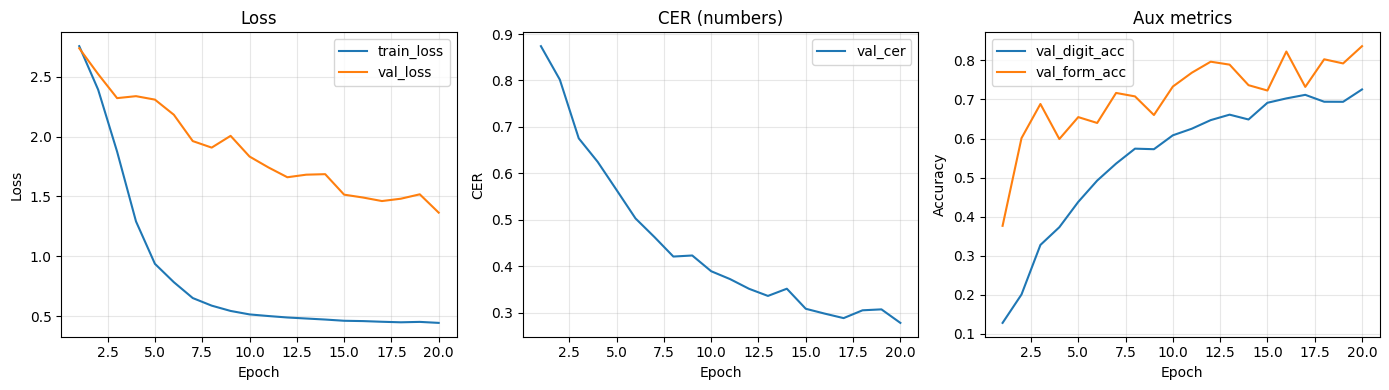

In [13]:
# Можно запускать повторно для дообучения: история сохраняется и графики остаются непрерывными.
history = train_model(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["dev"],
    optimizer=optimizer,
    device=DEVICE,
    num_epochs=5,
    tf_ratio=TF_RATIO,
    history=history,
)



In [14]:
# Папка для чекпоинтов
CKPT_DIR = PROJECT_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_name = f"structured_conformer_с27.pt"
ckpt_path = CKPT_DIR / ckpt_name

In [15]:
# Сохраняем состояние обучения
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if "optimizer" in globals() else None,
        "history": history if "history" in globals() else None,
        "model_class": "StructuredConformerModel",
    },
    ckpt_path,
)

print(f"Checkpoint saved: {ckpt_path}")

Checkpoint saved: C:\Users\tosha\PycharmProjects\SpeechCourse\project1\checkpoints\structured_conformer_с27.pt


In [10]:
# ckpt = torch.load(ckpt_path, map_location=DEVICE)
# model = StructuredConformerModel().to(DEVICE)
# model.load_state_dict(ckpt["model_state_dict"])
# optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
# optimizer.load_state_dict(ckpt["optimizer_state_dict"])
# history = ckpt.get("history", {"epoch": [], "train_loss": [], "val_loss": [], "val_cer": [], "val_digit_acc": [], "val_form_acc": []})
# model.eval()  # если нужен инференс

StructuredConformerModel(
  (melspec): MelSpectrogram(
    (spectrogram): Spectrogram()
    (mel_scale): MelScale()
  )
  (to_db): AmplitudeToDB()
  (freq_mask): FrequencyMasking()
  (time_mask): TimeMasking()
  (input_norm): LayerNorm((80,), eps=1e-05, elementwise_affine=True)
  (in_proj): Linear(in_features=80, out_features=144, bias=True)
  (encoder): Conformer(
    (conformer_layers): ModuleList(
      (0-5): 6 x ConformerLayer(
        (ffn1): _FeedForwardModule(
          (sequential): Sequential(
            (0): LayerNorm((144,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=144, out_features=384, bias=True)
            (2): SiLU()
            (3): Dropout(p=0.1, inplace=False)
            (4): Linear(in_features=384, out_features=144, bias=True)
            (5): Dropout(p=0.1, inplace=False)
          )
        )
        (self_attn_layer_norm): LayerNorm((144,), eps=1e-05, elementwise_affine=True)
        (self_attn): MultiheadAttention(
          (ou

In [16]:
# Submission function

def make_submission(
    model: nn.Module,
    test_loader: DataLoader,
    output_csv_path: str | Path,
    device: str | torch.device,
) -> Path:
    device = torch.device(device)
    model.to(device)
    model.eval()

    filenames: List[str] = []
    predictions: List[str] = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Submission")
        for batch in pbar:
            waveforms = batch["waveforms"].to(device)
            lengths = batch["lengths"].to(device)
            batch_filenames = batch["filenames"]

            out = model(waveforms, lengths, target_digits=None, teacher_forcing=False)
            pred_numbers = decode_digits_from_logits(out["digit_logits"])

            for n in pred_numbers:
                n = min(max(n, 1000), 999999)
                predictions.append(str(n))
            filenames.extend(batch_filenames)

    output_csv_path = Path(output_csv_path)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    with output_csv_path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "transcription"])
        for fn, pred in zip(filenames, predictions):
            writer.writerow([fn, pred])

    print(f"Saved submission: {output_csv_path}")
    return output_csv_path



In [17]:
# Submission cell
submission_path = make_submission(
    model=model,
    test_loader=loaders["test"],
    output_csv_path=PROJECT_DIR / "submission_structured_conformer.csv",
    device=DEVICE,
)

with submission_path.open("r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().strip())


Submission:   0%|          | 0/162 [00:00<?, ?it/s]

Saved submission: C:\Users\tosha\PycharmProjects\SpeechCourse\project1\submission_structured_conformer.csv
filename,transcription
test/d2440788a9.mp3,461194
test/e247dbf761.mp3,204128
test/071f4a5be7.mp3,79087
test/798bd15db7.mp3,64108
